In [1]:
import pandas as pd

DATA_PATH = "../data/raw/Loan_default.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Loan Default Risk & Credit Analytics

## Project Objective

The objective of this project is to analyze customer loan and financial data, identify factors associated with loan default, and build a machine learning system to estimate default risk.

### Key Goals

- Perform data quality checks and exploratory data analysis (EDA)
- Understand customer and loan characteristics associated with default
- Engineer relevant features for machine learning
- Compare multiple classification models
- Evaluate models using appropriate metrics for imbalanced data
- Optimize the decision threshold based on business requirements
- Build a reusable prediction pipeline

## 1. Data Overview

We begin by examining the size, structure, data types, and basic characteristics of the dataset.

In [2]:
print(f"Dataset shape: {df.shape}")

print("\nColumn information:")
df.info()

Dataset shape: (255347, 18)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     25

## 2. Missing Value Analysis

We check whether any columns contain missing values before proceeding with further analysis.

In [4]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Total missing values: 0


## 3. Duplicate Record Analysis

We check for duplicate records to ensure that repeated observations do not affect the analysis or model training.

In [5]:
duplicate_rows = df.duplicated().sum()
duplicate_loan_ids = df["LoanID"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate LoanIDs: {duplicate_loan_ids}")

Duplicate rows: 0
Duplicate LoanIDs: 0


## 4. Target Variable Distribution

The target variable `Default` indicates whether a loan resulted in default:

- `0` → No default
- `1` → Default

Because the target is imbalanced, model evaluation should not rely on accuracy alone.

In [6]:
target_counts = df["Default"].value_counts().sort_index()
target_percentages = df["Default"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
Default,,
0,225694,88.39
1,29653,11.61


## 5. Default Distribution Visualization

The distribution of the target variable is visualized to clearly understand the class imbalance in the dataset.

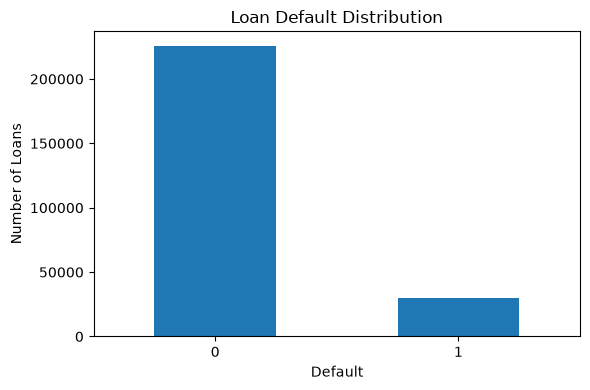

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Numerical Feature Summary

We examine the distribution of numerical loan and customer attributes using descriptive statistics.

In [9]:
numeric_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


## 7. Numerical Feature Distributions

We visualize the distributions of numerical features to understand their spread, concentration, and potential skewness.

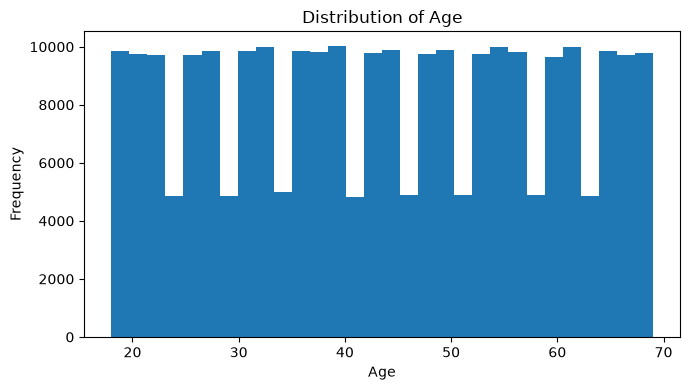

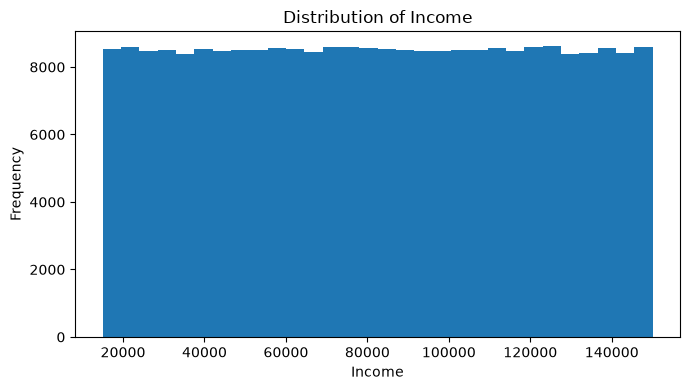

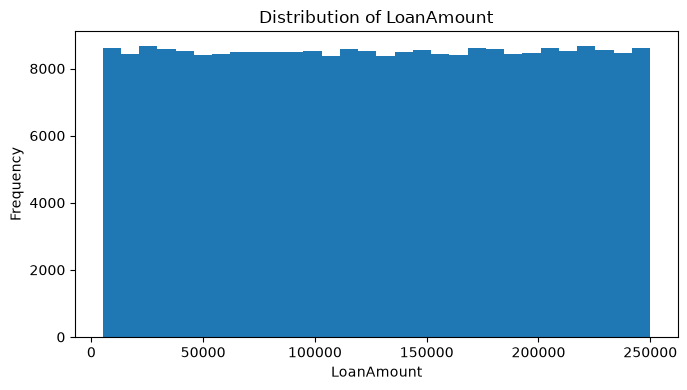

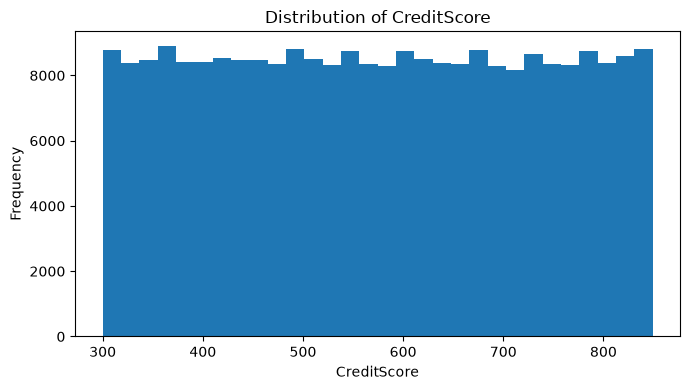

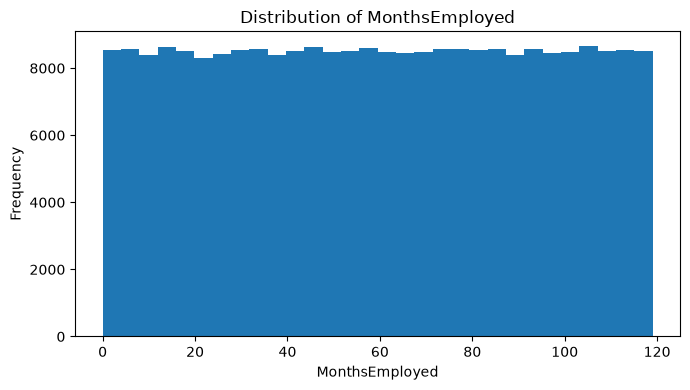

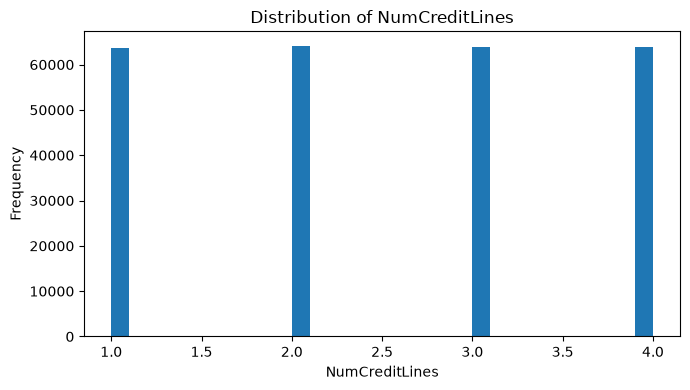

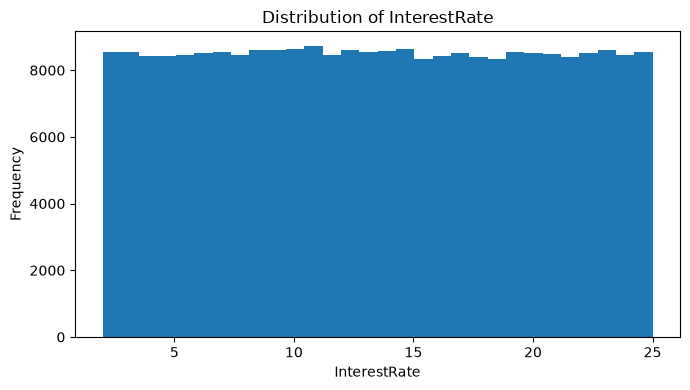

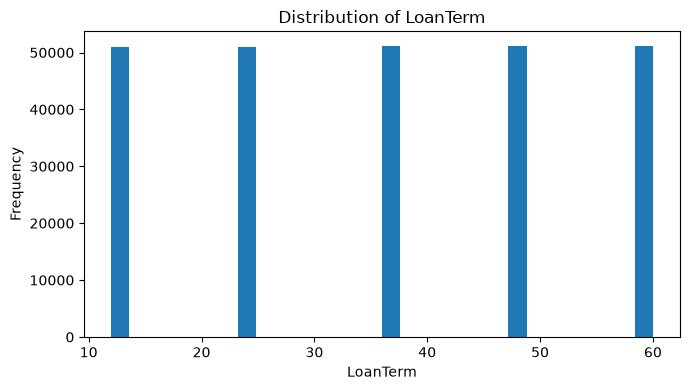

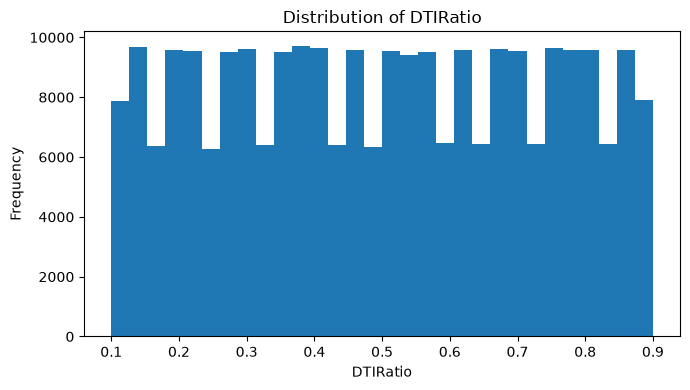

In [10]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

A correlation matrix is used to examine linear relationships between numerical features and the loan default target.

This helps identify features that may have useful predictive relationships while avoiding conclusions based on correlation alone.

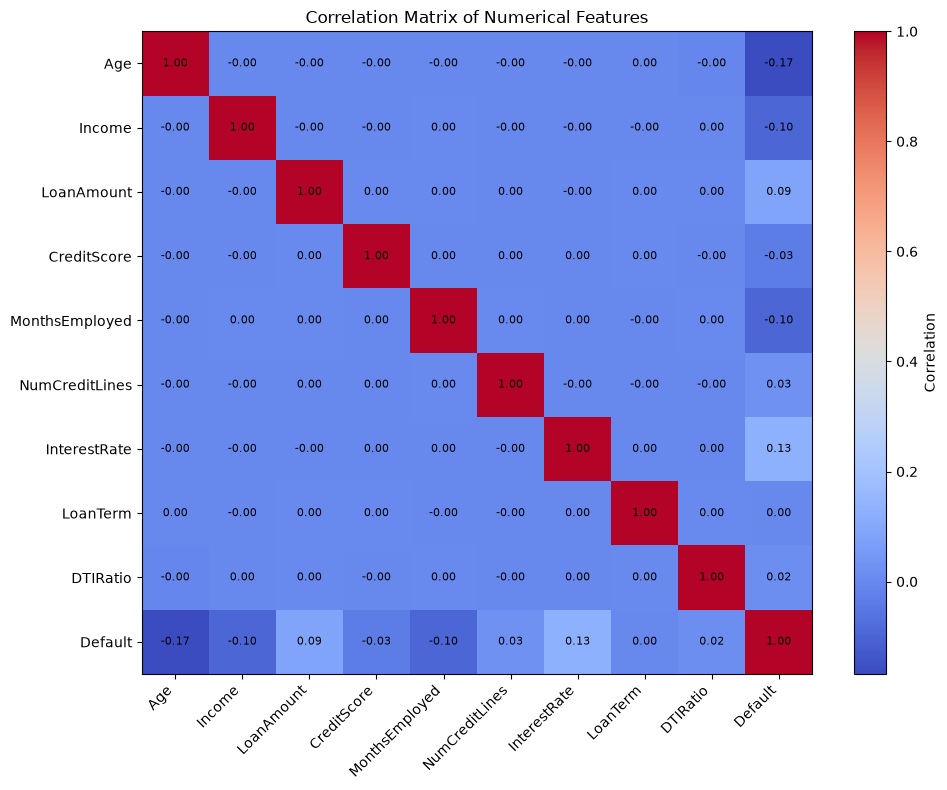

In [11]:
correlation_columns = numeric_columns + ["Default"]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 9. Default Rate by Categorical Features

We compare default rates across customer and loan categories to identify groups with relatively higher or lower observed default rates.

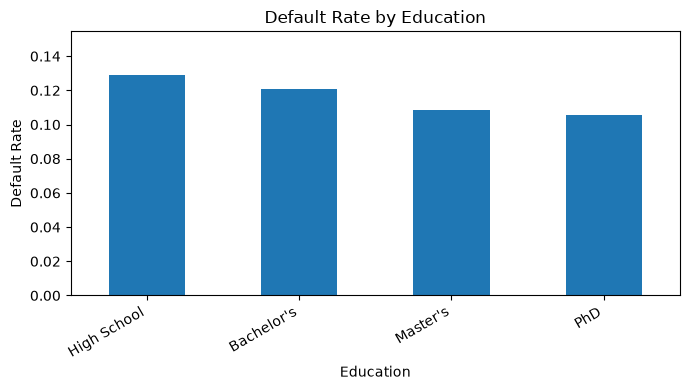

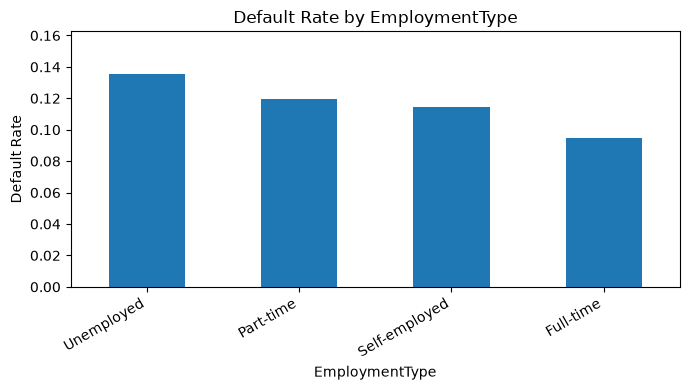

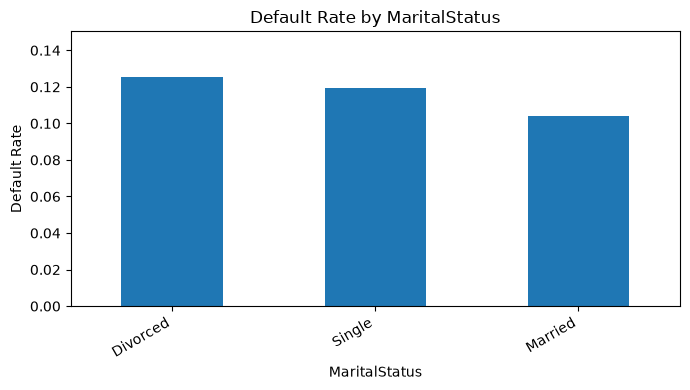

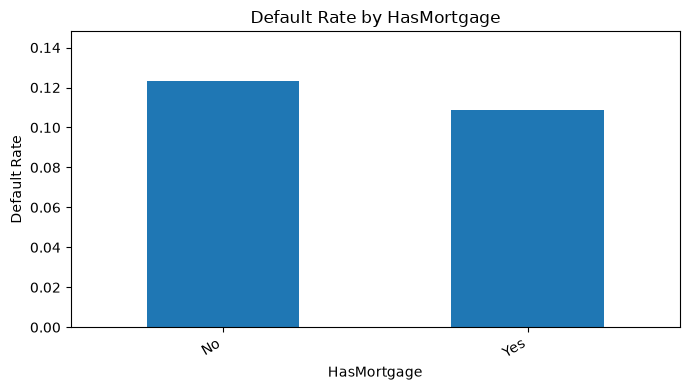

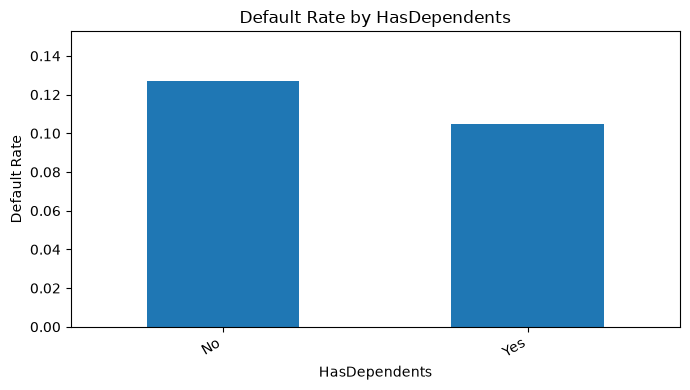

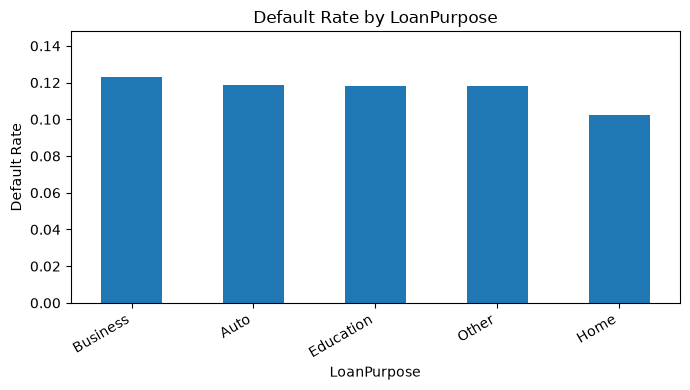

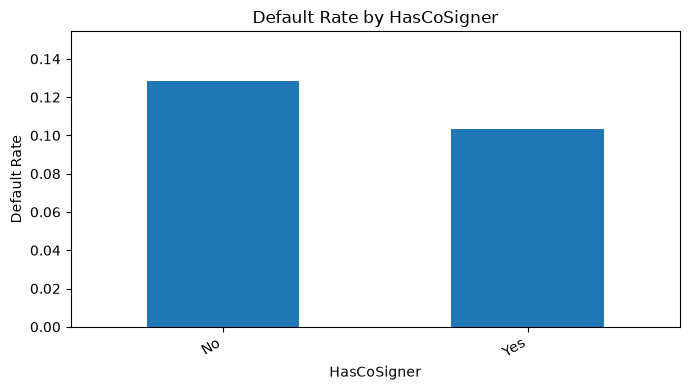

In [12]:
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for column in categorical_columns:
    default_rate = (
        df.groupby(column)["Default"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(7, 4))
    default_rate.plot(kind="bar")

    plt.title(f"Default Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Default Rate")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, default_rate.max() * 1.2)
    plt.tight_layout()
    plt.show()

## 10. Numerical Features by Default Status

We compare numerical loan and customer characteristics between default and non-default groups to identify differences in their observed distributions.

<Figure size 700x400 with 0 Axes>

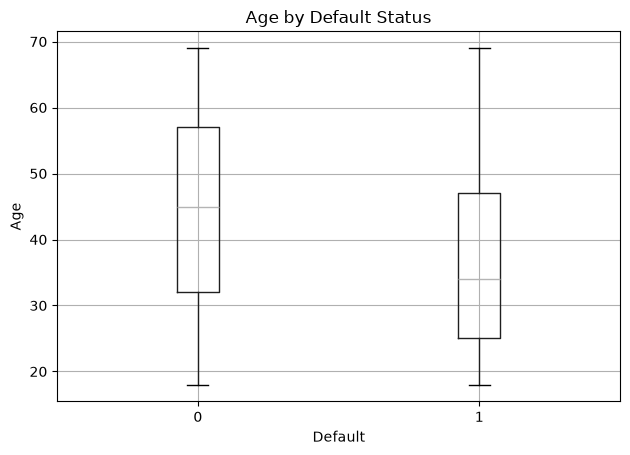

<Figure size 700x400 with 0 Axes>

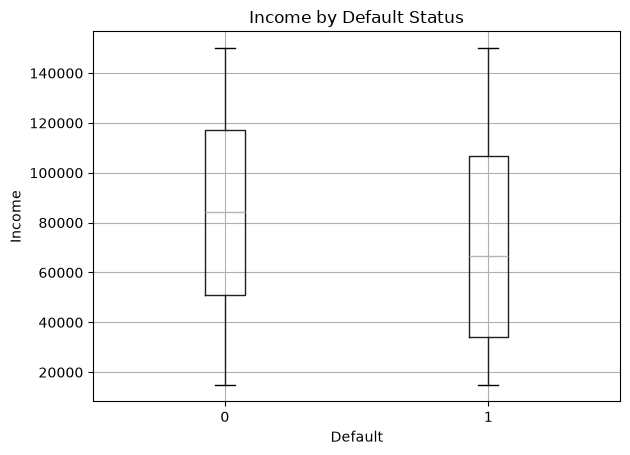

<Figure size 700x400 with 0 Axes>

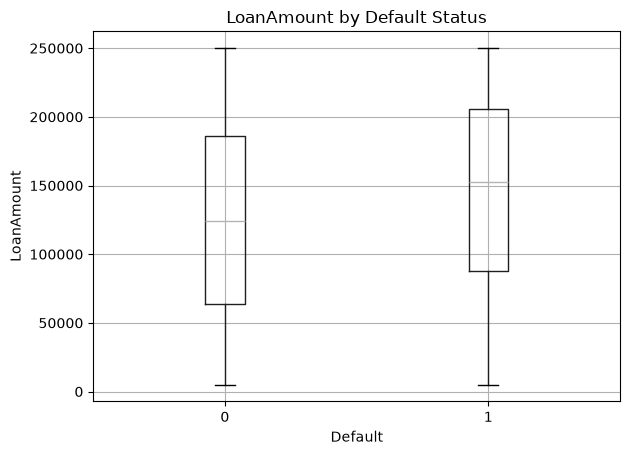

<Figure size 700x400 with 0 Axes>

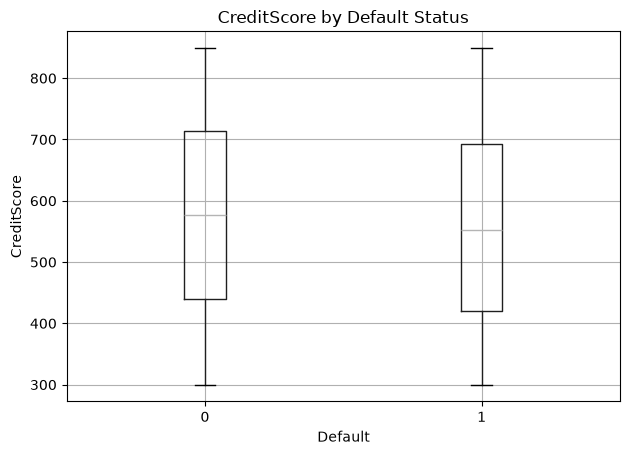

<Figure size 700x400 with 0 Axes>

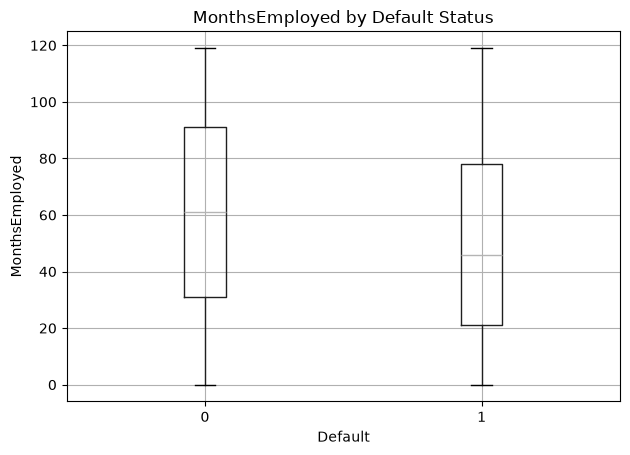

<Figure size 700x400 with 0 Axes>

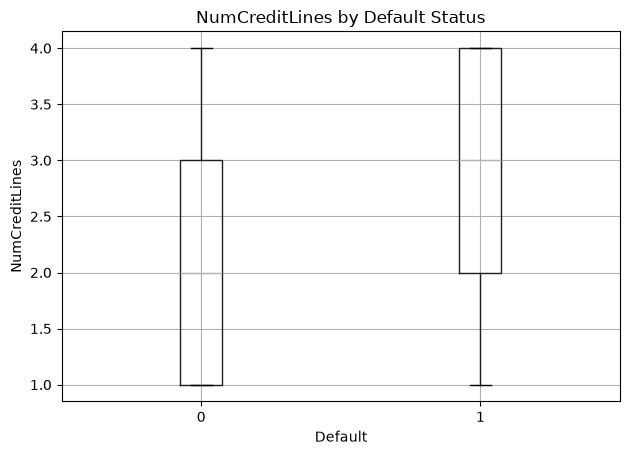

<Figure size 700x400 with 0 Axes>

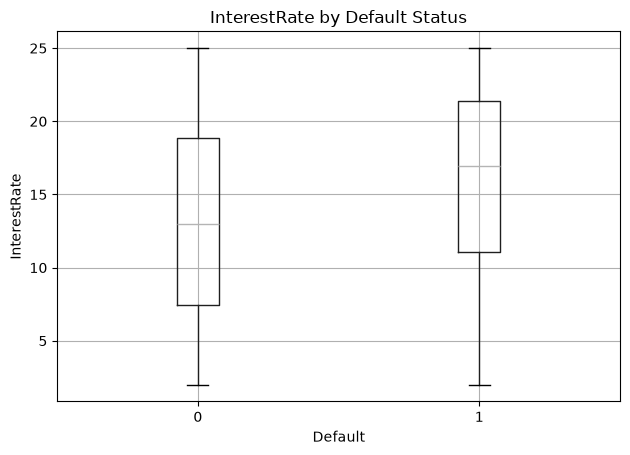

<Figure size 700x400 with 0 Axes>

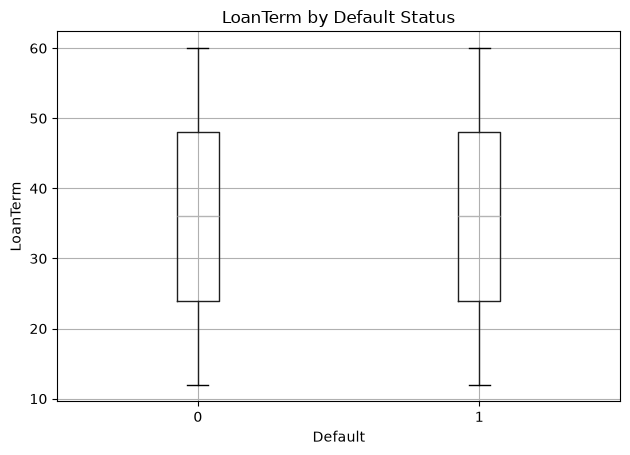

<Figure size 700x400 with 0 Axes>

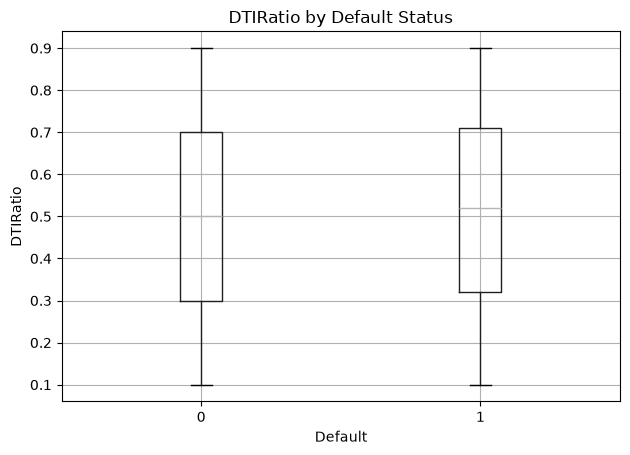

In [13]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    df.boxplot(
        column=column,
        by="Default"
    )

    plt.title(f"{column} by Default Status")
    plt.suptitle("")
    plt.xlabel("Default")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

## 11. Employment Duration and Default Risk

The `MonthsEmployed` feature contains observations with a value of zero. Instead of treating these values as missing automatically, we compare their observed default rate with applicants who have at least one month of employment history.

In [14]:
employment_status = df["MonthsEmployed"].eq(0)

employment_default_summary = (
    df.groupby(employment_status)["Default"]
    .agg(["count", "mean"])
    .rename(index={
        False: "MonthsEmployed > 0",
        True: "MonthsEmployed = 0"
    })
)

employment_default_summary["default_rate_percent"] = (
    employment_default_summary["mean"] * 100
).round(2)

employment_default_summary

,count,mean,default_rate_percent
MonthsEmployed,,,
MonthsEmployed > 0,253225,0.115581,11.56
MonthsEmployed = 0,2122,0.181433,18.14


## 12. Loan-to-Income Ratio

The loan-to-income ratio measures the size of a loan relative to the borrower's income. A higher ratio may indicate greater borrowing exposure relative to income.

In [15]:
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["Income"]

df["LoanToIncomeRatio"].describe()

count    255347.000000
mean          2.177480
std           2.178357
min           0.033749
25%           0.803628
50%           1.546720
75%           2.671744
max          16.532460
Name: LoanToIncomeRatio, dtype: float64

## 13. Loan-to-Income Ratio and Default Risk

We examine whether borrowers with higher loan-to-income ratios show different observed default rates.

In [16]:
lti_default_correlation = df["LoanToIncomeRatio"].corr(df["Default"])

print(
    f"Correlation between LoanToIncomeRatio and Default: "
    f"{lti_default_correlation:.4f}"
)

Correlation between LoanToIncomeRatio and Default: 0.1790


## 14. Loan-to-Income Ratio by Default Status

We compare the loan-to-income ratio distribution between default and non-default borrowers to understand whether higher borrowing relative to income is associated with different observed risk levels.

<Figure size 800x500 with 0 Axes>

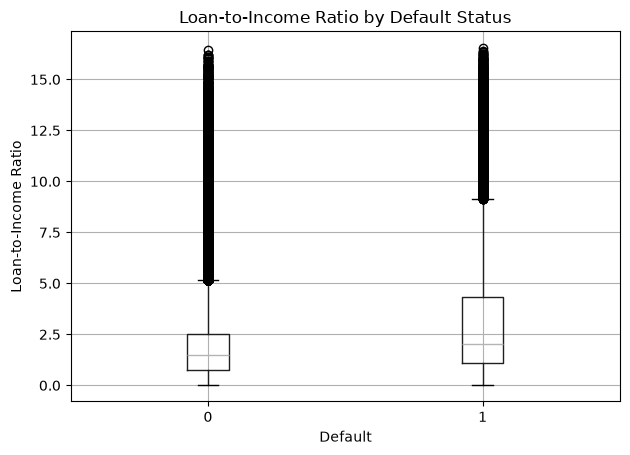

In [17]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="LoanToIncomeRatio",
    by="Default"
)

plt.title("Loan-to-Income Ratio by Default Status")
plt.suptitle("")
plt.xlabel("Default")
plt.ylabel("Loan-to-Income Ratio")
plt.tight_layout()
plt.show()

## 15. Credit Score Risk Bands

Credit score is grouped into risk bands to examine how observed default rates vary across different credit score ranges.

In [18]:
credit_bins = [0, 499, 599, 699, 799, 900]
credit_labels = [
    "<500",
    "500-599",
    "600-699",
    "700-799",
    "800+"
]

df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=credit_bins,
    labels=credit_labels,
    right=True,
    include_lowest=True
)

credit_risk_summary = (
    df.groupby("CreditScoreBand", observed=False)["Default"]
    .agg(["count", "mean"])
)

credit_risk_summary["default_rate_percent"] = (
    credit_risk_summary["mean"] * 100
).round(2)

credit_risk_summary

,count,mean,default_rate_percent
CreditScoreBand,,,
<500,93029,0.127734,12.77
500-599,46454,0.118268,11.83
600-699,46434,0.111772,11.18
700-799,45962,0.104064,10.41
800+,23468,0.098134,9.81


## 16. Default Rate Across Credit Score Bands

The default rate is visualized across credit score bands to make the observed risk pattern easier to interpret.

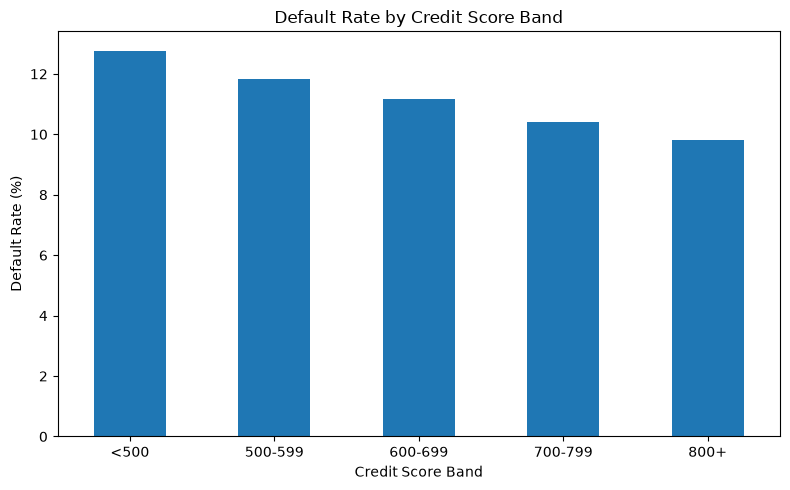

In [20]:
plt.figure(figsize=(8, 5))

credit_risk_summary["default_rate_percent"].plot(kind="bar")

plt.title("Default Rate by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Debt-to-Income Ratio Risk Bands

The debt-to-income ratio is grouped into risk bands to examine whether observed default rates differ across levels of existing debt burden relative to income.

In [21]:
dti_bins = [0, 0.3, 0.5, 0.7, 1.0]
dti_labels = [
    "<=30%",
    "31-50%",
    "51-70%",
    ">70%"
]

df["DTIRiskBand"] = pd.cut(
    df["DTIRatio"],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True
)

dti_risk_summary = (
    df.groupby("DTIRiskBand", observed=False)["Default"]
    .agg(["count", "mean"])
)

dti_risk_summary["default_rate_percent"] = (
    dti_risk_summary["mean"] * 100
).round(2)

dti_risk_summary

,count,mean,default_rate_percent
DTIRiskBand,,,
<=30%,65248,0.106593,10.66
31-50%,63970,0.115351,11.54
51-70%,63781,0.119879,11.99
>70%,62348,0.123067,12.31


## 18. Default Rate Across DTI Risk Bands

The default rate is visualized across debt-to-income ratio bands to make the observed relationship easier to interpret.

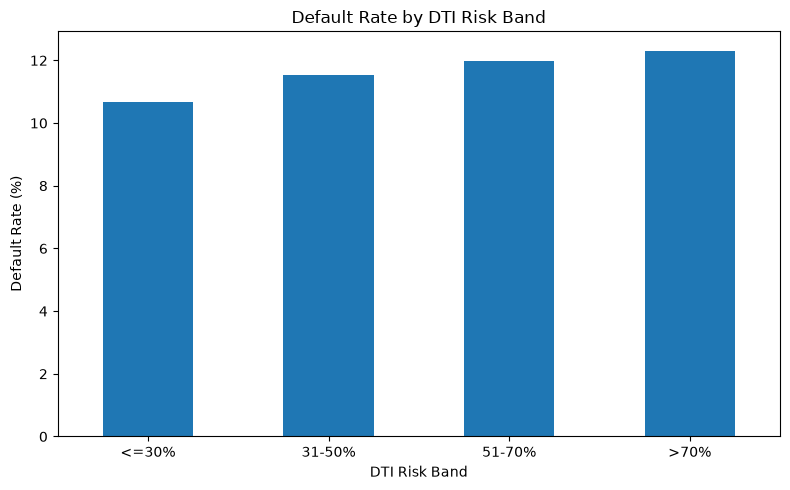

In [22]:
plt.figure(figsize=(8, 5))

dti_risk_summary["default_rate_percent"].plot(kind="bar")

plt.title("Default Rate by DTI Risk Band")
plt.xlabel("DTI Risk Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Feature Selection for Modeling

Before model development, we separate identifiers, target variables, original features, and engineered features.

`LoanID` is excluded because it is an identifier and does not represent meaningful customer or loan characteristics.

The engineered risk features will be evaluated alongside the original features during model development.

In [23]:
target_column = "Default"

excluded_columns = [
    "LoanID",
    target_column
]

engineered_features = [
    "LoanToIncomeRatio",
    "CreditScoreBand",
    "DTIRiskBand"
]

model_features = [
    column
    for column in df.columns
    if column not in excluded_columns
]

print("Target column:")
print(target_column)

print("\nExcluded columns:")
print(excluded_columns)

print("\nEngineered features:")
print(engineered_features)

print("\nTotal candidate modeling features:", len(model_features))
print("\nCandidate modeling features:")
print(model_features)

Target column:
Default

Excluded columns:
['LoanID', 'Default']

Engineered features:
['LoanToIncomeRatio', 'CreditScoreBand', 'DTIRiskBand']

Total candidate modeling features: 19

Candidate modeling features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'LoanToIncomeRatio', 'CreditScoreBand', 'DTIRiskBand']


## 20. EDA Summary

The exploratory analysis identified several useful patterns in the loan portfolio:

- The target variable is imbalanced, with defaults representing approximately 11.61% of observations.
- The dataset contains no missing values or duplicate records.
- `LoanID` is an identifier and is excluded from modeling.
- `InterestRate`, `LoanAmount`, and `LoanToIncomeRatio` show positive observed relationships with default.
- Higher credit score bands show progressively lower observed default rates.
- Higher DTI bands show progressively higher observed default rates.
- Applicants with zero recorded months of employment have a higher observed default rate than applicants with at least one month of employment.
- Several categorical variables show differences in observed default rates across their groups.
- Engineered features such as `LoanToIncomeRatio`, `CreditScoreBand`, and `DTIRiskBand` will be evaluated during model development.

These observations are exploratory and do not imply causation. Final feature usefulness will be determined through model training and evaluation on unseen data.